# Import libraries

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import mlflow
import mlflow.sklearn

# Read data

In [3]:
df = pd.read_parquet("/Users/giakhanh/Desktop/AIDE/Projects/home_credit_risk/data/processed/train_v1.parquet")
df.head()

,sk_id_curr,target,contract_type,gender_code,owns_car_flag,owns_realty_flag,children_count,family_status,accompany_type,income_total_amt,...,previous_cc_max_balance_max_flag,previous_cc_avg_limit_mean_flag,previous_cc_avg_dpd_mean_flag,bureau_avg_amt_annuity_flag,bureau_max_amt_annuity_flag,bureau_balance_max_dpd_severity_flag,ext_source_3_missing_flag,employment_years_missing_flag,days_employed_clean_missing_flag,ext_source_1_missing_flag
0,284594,0,Cash loans,F,N,N,0,Married,Unaccompanied,81000.0,...,0,0,0,0,0,0,0,0,0,0
1,284605,0,Cash loans,F,N,Y,0,Single / not married,Family,180000.0,...,1,1,1,0,0,0,0,0,0,1
2,284611,0,Cash loans,M,Y,Y,1,Married,Unaccompanied,180000.0,...,0,0,0,0,0,0,1,0,0,0
3,284977,0,Cash loans,M,N,Y,2,Married,Unaccompanied,67500.0,...,1,1,1,0,0,1,0,0,0,1
4,285021,0,Revolving loans,F,N,Y,0,Married,Family,90000.0,...,0,0,0,0,0,0,1,0,0,0


# Train-Test Split

In [8]:
X = df.drop(columns=['target'])
y = df['target']

In [9]:
print(X.shape)
print(y.shape)

(307511, 269)
(307511,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.2,
                                                    random_state=42,
                                                    stratify=y           # Cause data is imbalance
                                                    )

print(f"\nData shapes after splitting:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

# Check target ratio in train and validation
print(f"\nTarget ratio in train set: {y_train.mean():.4f}")
print(f"Target ratio in validation set: {y_test.mean():.4f}")


Data shapes after splitting:
X_train: (246008, 269)
X_val: (61503, 269)
y_train: (246008,)
y_val: (61503,)

Target ratio in train set: 0.0807
Target ratio in validation set: 0.0807


# Train in baseline dataset

## Logistic Regression

### Define categorical and numerical features

In [16]:
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

print("Categorical columns:", len(categorical_cols))
print("Numerical columns:", len(numerical_cols))

Categorical columns: 12
Numerical columns: 257


In [17]:
X_train_cat = X_train[categorical_cols].copy()
X_test_cat = X_test[categorical_cols].copy()

X_train_num = X_train[numerical_cols].copy()
X_test_num = X_test[numerical_cols].copy()

### One hot Encoder

In [42]:
ohe = OneHotEncoder(handle_unknown = "ignore", sparse_output = False)

X_train_cat_encoded = ohe.fit_transform(X_train_cat)
X_test_cat_encoded = ohe.transform(X_test_cat)

In [43]:
print("Encoded categorical shape (train):", X_train_cat_encoded.shape)
print("Encoded categorical shape (test):", X_test_cat_encoded.shape)
print("Ecoded categorical type (train): ", type(X_train_cat_encoded))
print("Ecoded categorical type (test): ", type(X_test_cat_encoded))

Encoded categorical shape (train): (246008, 126)
Encoded categorical shape (test): (61503, 126)
Ecoded categorical type (train):  <class 'numpy.ndarray'>
Ecoded categorical type (test):  <class 'numpy.ndarray'>


### Convert endcoded data to DataFrame

In [44]:
encoded_cat_features = ohe.get_feature_names_out(categorical_cols)

print("Encoded categorical shape (train):", X_train_cat_encoded.shape)
print("Encoded categorical shape (test):", X_test_cat_encoded.shape)
print(encoded_cat_features[:20])

Encoded categorical shape (train): (246008, 126)
Encoded categorical shape (test): (61503, 126)
['contract_type_Cash loans' 'contract_type_Revolving loans'
 'gender_code_F' 'gender_code_M' 'gender_code_XNA' 'owns_car_flag_N'
 'owns_car_flag_Y' 'owns_realty_flag_N' 'owns_realty_flag_Y'
 'family_status_Civil marriage' 'family_status_Married'
 'family_status_Separated' 'family_status_Single / not married'
 'family_status_Unknown' 'family_status_Widow' 'accompany_type_Children'
 'accompany_type_Family' 'accompany_type_Group of people'
 'accompany_type_Other_A' 'accompany_type_Other_B']


In [45]:
X_train_cat_encoded_df = pd.DataFrame(
    X_train_cat_encoded,
    columns = encoded_cat_features,
    index = X_train_cat.index
)

X_test_cat_encoded_df = pd.DataFrame(
    X_test_cat_encoded,
    columns = encoded_cat_features,
    index = X_test_cat.index
)

### Feature Scaling

In [30]:
scaler = StandardScaler()

X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

In [35]:
print("Standardized training and validation data")
print(f"X_train_scaled shape: {X_train_num_scaled.shape}")
print(f"X_test_scaled shape: {X_test_num_scaled.shape}")

# Check statistics after standardization
print(f"\nStatistics after standardization:")
print(f"Mean of X_train_scaled: {X_train_num_scaled.mean():.6f}")
print(f"Std of X_train_scaled: {X_train_num_scaled.std():.6f}")
print(f"Mean of X_test_scaled: {X_test_num_scaled.mean():.6f}")
print(f"Std of X_test_scaled: {X_test_num_scaled.std():.6f}")

print(f"\nType of X_train data after scaling: {type(X_train_num_scaled)}")
print(f"Type of X_test data after scaling: {type(X_test_num_scaled)}")

Standardized training and validation data
X_train_scaled shape: (246008, 257)
X_test_scaled shape: (61503, 257)

Statistics after standardization:
Mean of X_train_scaled: 0.000000
Std of X_train_scaled: 1.000000
Mean of X_test_scaled: 0.000598
Std of X_test_scaled: 1.274107

Type of X_train data after scaling: <class 'numpy.ndarray'>
Type of X_test data after scaling: <class 'numpy.ndarray'>


### Convert scaled data to DataFrame

In [36]:
X_train_num_scaled_df = pd.DataFrame(
    X_train_num_scaled,
    columns=numerical_cols,
    index=X_train_num.index
)

X_test_num_scaled_df = pd.DataFrame(
    X_test_num_scaled,
    columns=numerical_cols,
    index=X_test_num.index
)

### Concat numerical + categorical

In [46]:
X_train_processed = pd.concat(
    [X_train_num_scaled_df, X_train_cat_encoded_df],
    axis=1
)

X_test_processed = pd.concat(
    [X_test_num_scaled_df, X_test_cat_encoded_df],
    axis=1
)

print("Train processed shape:", X_train_processed.shape)
print("Test processed shape:", X_test_processed.shape)

Train processed shape: (246008, 383)
Test processed shape: (61503, 383)


## Training Logistic Regression

### Input data

In [91]:
print("Train shape:", X_train_processed.shape)
print("Test shape :", X_test_processed.shape)
print("Train target distribution:", pd.Series(y_train).value_counts(normalize=True).to_dict())
print("Test target distribution :", pd.Series(y_test).value_counts(normalize=True).to_dict())

Train shape: (246008, 383)
Test shape : (61503, 383)
Train target distribution: {0: 0.9192709180189262, 1: 0.08072908198107379}
Test target distribution : {0: 0.9192722306228964, 1: 0.08072776937710356}


### Define CV + MLflow experiment

In [93]:
cv = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

In [145]:
mlflow.set_experiment("home_credit_models_pipeline")

print("MLflow experiment is ready.")

MLflow experiment is ready.


### Train and hyperparameter tuning with GridSearchCV

In [97]:
param_grid = [
    {
        "solver": ["lbfgs"],
        "penalty": ["l2"],
        "C": [0.01, 0.1, 1.0, 10.0],
        "class_weight": ["balanced"],
        "max_iter": [1000]
    },

    {
        "solver": ["liblinear"],
        "penalty": ["l1", "l2"],
        "C": [0.01, 0.1, 1.0, 10.0],
        "class_weight": ["balanced"],
        "max_iter": [1000]
    },

    {
        "solver": ["saga"],
        "penalty": ["l1", "l2"],
        "C": [0.01, 0.1, 1.0, 10.0],
        "class_weight": ["balanced"],
        "max_iter": [1000]
    }
]

base_model = LogisticRegression(random_state = 42)

with mlflow.start_run(run_name = "logistic_gridsearch_training") as train_run:
    train_run_id = train_run.info.run_id

    mlflow.log_param("test_size", 0.15)
    mlflow.log_param("cv_n_splits", 5)
    mlflow.log_param("cv_shuffle", True)
    mlflow.log_param("cv_random_state", 42)
    mlflow.log_param("scoring", "f1")
    mlflow.log_param("model_type", "LogisticRegression")

    grid = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True,
        return_train_score=True
    )

    grid.fit(X_train_processed, y_train)

    best_model = grid.best_estimator_

    print("\n=== BEST HYPERPARAMETERS ===")
    print("Best params :", grid.best_params_)
    print("Best CV F1  :", round(grid.best_score_, 6))

    # log best params
    for k, v in grid.best_params_.items():
        mlflow.log_param(f"best_{k}", v)

    mlflow.log_metric("best_cv_f1", grid.best_score_)

    # log model
    mlflow.sklearn.log_model(best_model, artifact_path="model")

print("Train run_id:", train_run_id)



Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Users/giakhanh/Desktop/AIDE/Projects/home_credit_risk/.venv/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/giakhanh/Desktop/AIDE/Projects/home_credit_risk/.venv/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:


=== BEST HYPERPARAMETERS ===
Best params : {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1  : 0.27623


2026/04/28 17:04:35 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/04/28 17:04:35 INFO mlflow.tracking._tracking_service.client: 🏃 View run logistic_gridsearch_training at: http://localhost:5002/#/experiments/868821111017111961/runs/2e0cf4d859cc46dbb5c0732a203bfda3.
2026/04/28 17:04:35 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://localhost:5002/#/experiments/868821111017111961.


Train run_id: 2e0cf4d859cc46dbb5c0732a203bfda3


In [98]:
cv_results_df = pd.DataFrame(grid.cv_results_)

display(
    cv_results_df[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "param_solver",
            "param_penalty",
            "param_C",
            "param_class_weight",
            "param_max_iter"
        ]
    ].sort_values("rank_test_score").head(10)
)

,rank_test_score,mean_test_score,std_test_score,param_solver,param_penalty,param_C,param_class_weight,param_max_iter
1,1,0.276230,0.002130,lbfgs,l2,0.1,balanced,1000
7,2,0.276202,0.002123,liblinear,l2,0.1,balanced,1000
8,3,0.276179,0.002186,liblinear,l1,1.0,balanced,1000
2,4,0.276157,0.002311,lbfgs,l2,1.0,balanced,1000
16,5,0.276125,0.002085,saga,l1,1.0,balanced,1000
19,6,0.276106,0.002042,saga,l2,10.0,balanced,1000
17,7,0.276100,0.002044,saga,l2,1.0,balanced,1000
18,8,0.276086,0.002060,saga,l1,10.0,balanced,1000
9,9,0.276078,0.002177,liblinear,l2,1.0,balanced,1000
11,10,0.276077,0.002165,liblinear,l2,10.0,balanced,1000


In [ ]:
cv_results_df = pd.DataFrame(grid.cv_results_)
cv_results_df.to_csv("../artifact/logistic_gridsearch_cv_results.csv", index=False)

In [144]:
with mlflow.start_run(run_id=train_run_id):
    mlflow.log_artifact("../artifact/logistic_gridsearch_cv_results.csv")

2026/04/29 17:27:53 INFO mlflow.tracking._tracking_service.client: 🏃 View run logistic_gridsearch_training at: http://localhost:5002/#/experiments/868821111017111961/runs/2e0cf4d859cc46dbb5c0732a203bfda3.
2026/04/29 17:27:53 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://localhost:5002/#/experiments/868821111017111961.


In [105]:
# Model information
print(f"\nModel information:")
print(f"Number of features: {best_model.n_features_in_}")
print(f"Number of iterations: {best_model.n_iter_[0]}")
print(f"Classes: {best_model.classes_}")


Model information:
Number of features: 383
Number of iterations: 605
Classes: [0 1]


In [102]:
# Model information
print(f"\nModel information:")
print(f"Number of features: {lr.n_features_in_}")
print(f"Number of iterations: {lr.n_iter_[0]}")
print(f"Classes: {lr.classes_}")


Model information:
Number of features: 383
Number of iterations: 1000
Classes: [0 1]


### Model predict and Evaluation

In [106]:
# Predict on validation set
print("🔮 MODEL PREDICTION AND EVALUATION")
print("=" * 40)

y_pred = best_model.predict(X_test_processed)
y_prob = best_model.predict_proba(X_test_processed)[:, 1]

print("Completed prediction on validation set")

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_prob)

print(f"\nMODEL EVALUATION RESULTS:")
print("=" * 40)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc_score:.4f}")

# Display classification report
print(f"\nCLASSIFICATION REPORT:")
print("=" * 40)
print(classification_report(y_test, y_pred))

🔮 MODEL PREDICTION AND EVALUATION
Completed prediction on validation set

MODEL EVALUATION RESULTS:
Accuracy:  0.7042
Precision: 0.1707
Recall:    0.6902
F1-Score:  0.2737
AUC-ROC:   0.7650

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.96      0.71      0.81     56538
           1       0.17      0.69      0.27      4965

    accuracy                           0.70     61503
   macro avg       0.57      0.70      0.54     61503
weighted avg       0.90      0.70      0.77     61503




CREATING EVALUATION VISUALIZATIONS


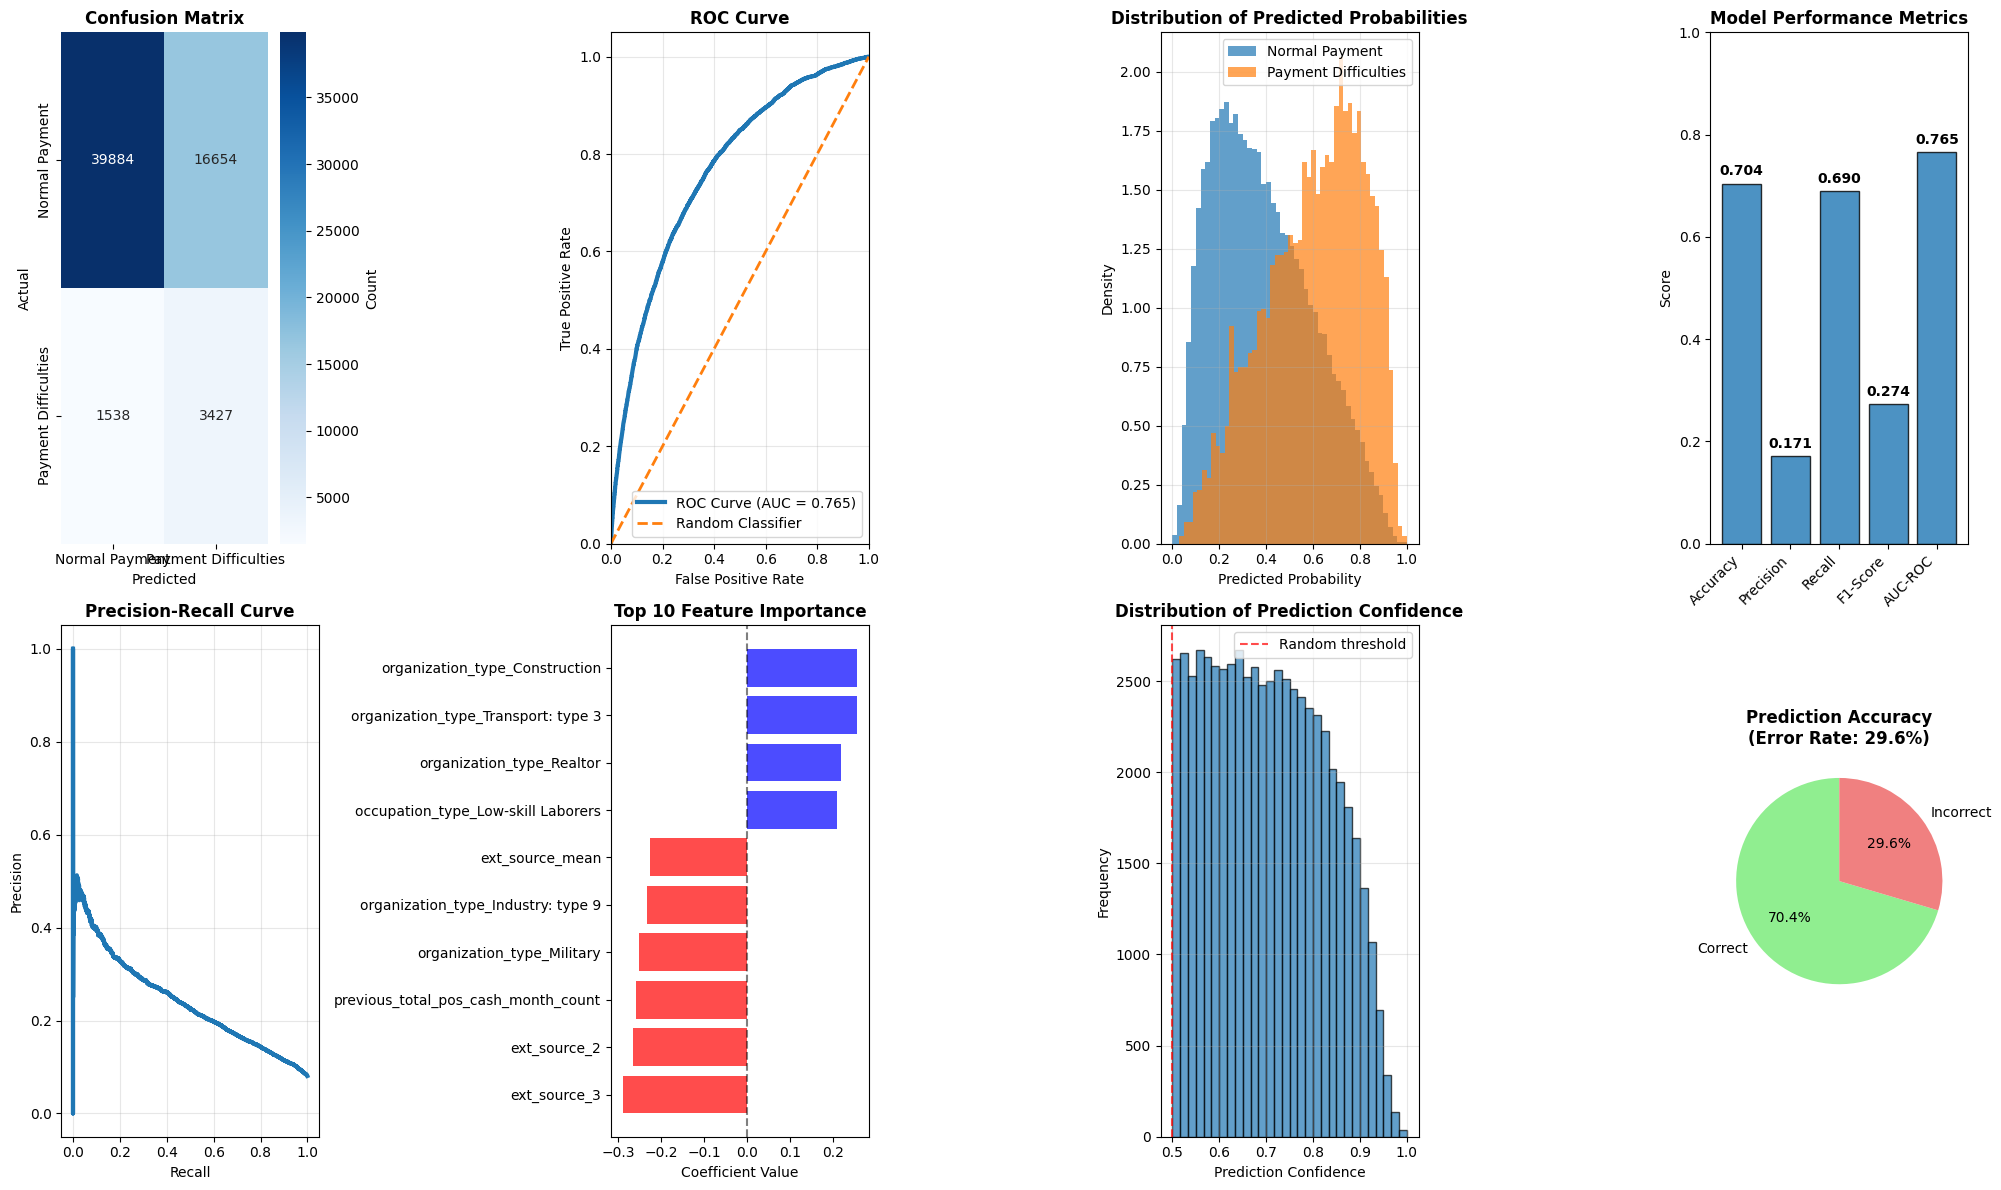


MODEL EVALUATION INSIGHTS:
• Model shows good performance (AUC: 0.765)
• Low precision: 0.171
• Moderate recall: 0.690
• F1-Score: 0.274 (Needs improvement)
• Accuracy: 0.704


In [107]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

print("\nCREATING EVALUATION VISUALIZATIONS")
print("=" * 50)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Create comprehensive evaluation plots
plt.figure(figsize=(20, 12))

# Plot 1: Confusion Matrix
plt.subplot(2, 4, 1)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal Payment', 'Payment Difficulties'],
    yticklabels=['Normal Payment', 'Payment Difficulties'],
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix', fontsize=12, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Plot 2: ROC Curve
plt.subplot(2, 4, 2)
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, lw=3, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontsize=12, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Plot 3: Distribution of predicted probabilities
plt.subplot(2, 4, 3)
plt.hist(y_prob[y_test == 0], bins=50, alpha=0.7, label='Normal Payment', density=True)
plt.hist(y_prob[y_test == 1], bins=50, alpha=0.7, label='Payment Difficulties', density=True)
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.title('Distribution of Predicted Probabilities', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: Metrics comparison
plt.subplot(2, 4, 4)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
values = [accuracy, precision, recall, f1, auc_score]

bars = plt.bar(metrics, values, alpha=0.8, edgecolor='black')
plt.title('Model Performance Metrics', fontsize=12, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{value:.3f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# Plot 5: Precision-Recall Curve
plt.subplot(2, 4, 5)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
plt.plot(recall_vals, precision_vals, lw=3)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# Plot 6: Feature importance (top 10)
plt.subplot(2, 4, 6)

feature_importance = pd.DataFrame({
    'Feature': X_train_processed.columns,
    'Coefficient': lr.coef_[0],
    'Abs_Coefficient': np.abs(lr.coef_[0])
})

top_features = feature_importance.nlargest(10, 'Abs_Coefficient').sort_values('Coefficient')

bar_colors = ['red' if x < 0 else 'blue' for x in top_features['Coefficient']]

plt.barh(top_features['Feature'], top_features['Coefficient'], color=bar_colors, alpha=0.7)
plt.xlabel('Coefficient Value')
plt.title('Top 10 Feature Importance', fontsize=12, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)

# Plot 7: Prediction confidence distribution
plt.subplot(2, 4, 7)
confidence = np.maximum(y_prob, 1 - y_prob)
plt.hist(confidence, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Prediction Confidence')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Confidence', fontsize=12, fontweight='bold')
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Random threshold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 8: Error analysis
plt.subplot(2, 4, 8)
errors = (y_test != y_pred).astype(int)
error_rate = errors.mean()
correct_rate = 1 - error_rate

plt.pie(
    [correct_rate, error_rate],
    labels=['Correct', 'Incorrect'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['lightgreen', 'lightcoral']
)
plt.title(f'Prediction Accuracy\n(Error Rate: {error_rate:.1%})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Analysis and insights
print("\nMODEL EVALUATION INSIGHTS:")
print("=" * 50)
print(f"• Model shows {'good' if auc_score > 0.7 else 'moderate' if auc_score > 0.6 else 'poor'} performance (AUC: {auc_score:.3f})")
print(f"• {'High' if precision > 0.7 else 'Moderate' if precision > 0.5 else 'Low'} precision: {precision:.3f}")
print(f"• {'High' if recall > 0.7 else 'Moderate' if recall > 0.5 else 'Low'} recall: {recall:.3f}")
print(f"• F1-Score: {f1:.3f} ({'Good' if f1 > 0.6 else 'Needs improvement'})")
print(f"• Accuracy: {accuracy:.3f}")

In [108]:
best_model.get_params()

{'C': 0.1,
 'class_weight': 'balanced',
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 1000,
 'multi_class': 'auto',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': 42,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

### Tunning Threshold


In [114]:
oof_prob = cross_val_predict(
    estimator=best_model,
    X=X_train_processed,
    y=y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
    verbose=0
)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.01)
threshold_results = []

with mlflow.start_run(run_name="logistic_threshold_tuning", nested=False) as threshold_run:
    threshold_run_id = threshold_run.info.run_id

    mlflow.log_param("source_train_run_id", train_run_id)
    mlflow.log_param("threshold_start", 0.05)
    mlflow.log_param("threshold_end", 0.95)
    mlflow.log_param("threshold_step", 0.01)
    mlflow.log_param("threshold_selection_metric", "f1")

    for t in thresholds:
        oof_pred = (oof_prob >= t).astype(int)

        precision = precision_score(y_train, oof_pred, zero_division=0)
        recall = recall_score(y_train, oof_pred, zero_division=0)
        f1 = f1_score(y_train, oof_pred, zero_division=0)
        acc = accuracy_score(y_train, oof_pred)

        threshold_results.append({
            "threshold": round(float(t), 2),
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "accuracy": acc
        })

    threshold_df = pd.DataFrame(threshold_results)

    best_row_f1 = threshold_df.loc[threshold_df["f1"].idxmax()]
    best_threshold_f1 = float(best_row_f1["threshold"])

    best_row_recall = threshold_df.loc[threshold_df["recall"].idxmax()]
    best_threshold_recall = float(best_row_recall["threshold"])

    selected_threshold = best_threshold_f1

    mlflow.log_metric("best_threshold_by_f1", best_threshold_f1)
    mlflow.log_metric("best_f1_at_selected_threshold", best_row_f1["f1"])
    mlflow.log_metric("precision_at_selected_threshold", best_row_f1["precision"])
    mlflow.log_metric("recall_at_selected_threshold", best_row_f1["recall"])
    mlflow.log_metric("accuracy_at_selected_threshold", best_row_f1["accuracy"])

print("Threshold run_id:", threshold_run_id)

print("\n=== BEST THRESHOLD BY F1 ===")
print(best_row_f1)

print("\n=== BEST THRESHOLD BY RECALL ===")
print(best_row_recall)

print("\nSelected threshold:", selected_threshold)

2026/04/29 16:25:36 INFO mlflow.tracking._tracking_service.client: 🏃 View run logistic_threshold_tuning at: http://localhost:5002/#/experiments/868821111017111961/runs/37ba132b738c4295bda059d630020ef9.
2026/04/29 16:25:36 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://localhost:5002/#/experiments/868821111017111961.


Threshold run_id: 37ba132b738c4295bda059d630020ef9

=== BEST THRESHOLD BY F1 ===
threshold    0.670000
precision    0.246314
recall       0.443353
f1           0.316687
accuracy     0.845546
Name: 62, dtype: float64

=== BEST THRESHOLD BY RECALL ===
threshold    0.050000
precision    0.081356
recall       0.999345
f1           0.150462
accuracy     0.088973
Name: 0, dtype: float64

Selected threshold: 0.67


In [124]:
display(threshold_df.sort_values("f1", ascending=False).head(10))

,threshold,precision,recall,f1,accuracy
62,0.67,0.246314,0.443353,0.316687,0.845546
61,0.66,0.240538,0.459517,0.315779,0.839241
64,0.69,0.256893,0.408610,0.315458,0.856838
63,0.68,0.250759,0.424421,0.315256,0.851159
65,0.70,0.262762,0.390584,0.314169,0.862334
60,0.65,0.234535,0.475176,0.314059,0.832432
59,0.64,0.230023,0.491793,0.313442,0.826075
58,0.63,0.225197,0.508157,0.312088,0.819152
66,0.71,0.268714,0.371450,0.311838,0.867651
57,0.62,0.220199,0.524320,0.310146,0.811701


In [122]:
print("🔮 MODEL PREDICTION AND EVALUATION")
print("=" * 40)

# Predict probability
y_test_proba = best_model.predict_proba(X_test_processed)[:, 1]

# Apply tuned threshold
y_pred = (y_test_proba >= selected_threshold).astype(int)

print("Completed prediction on test set")

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_test_proba)   # dùng proba

print(f"\nMODEL EVALUATION RESULTS:")
print("=" * 40)
print(f"Threshold: {selected_threshold:.2f}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc_score:.4f}")

print(f"\nCLASSIFICATION REPORT:")
print("=" * 40)
print(classification_report(y_test, y_pred))

🔮 MODEL PREDICTION AND EVALUATION
Completed prediction on test set

MODEL EVALUATION RESULTS:
Threshold: 0.67
Accuracy:  0.8471
Precision: 0.2470
Recall:    0.4363
F1-Score:  0.3154
AUC-ROC:   0.7650

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.95      0.88      0.91     56538
           1       0.25      0.44      0.32      4965

    accuracy                           0.85     61503
   macro avg       0.60      0.66      0.61     61503
weighted avg       0.89      0.85      0.87     61503




CREATING EVALUATION VISUALIZATIONS


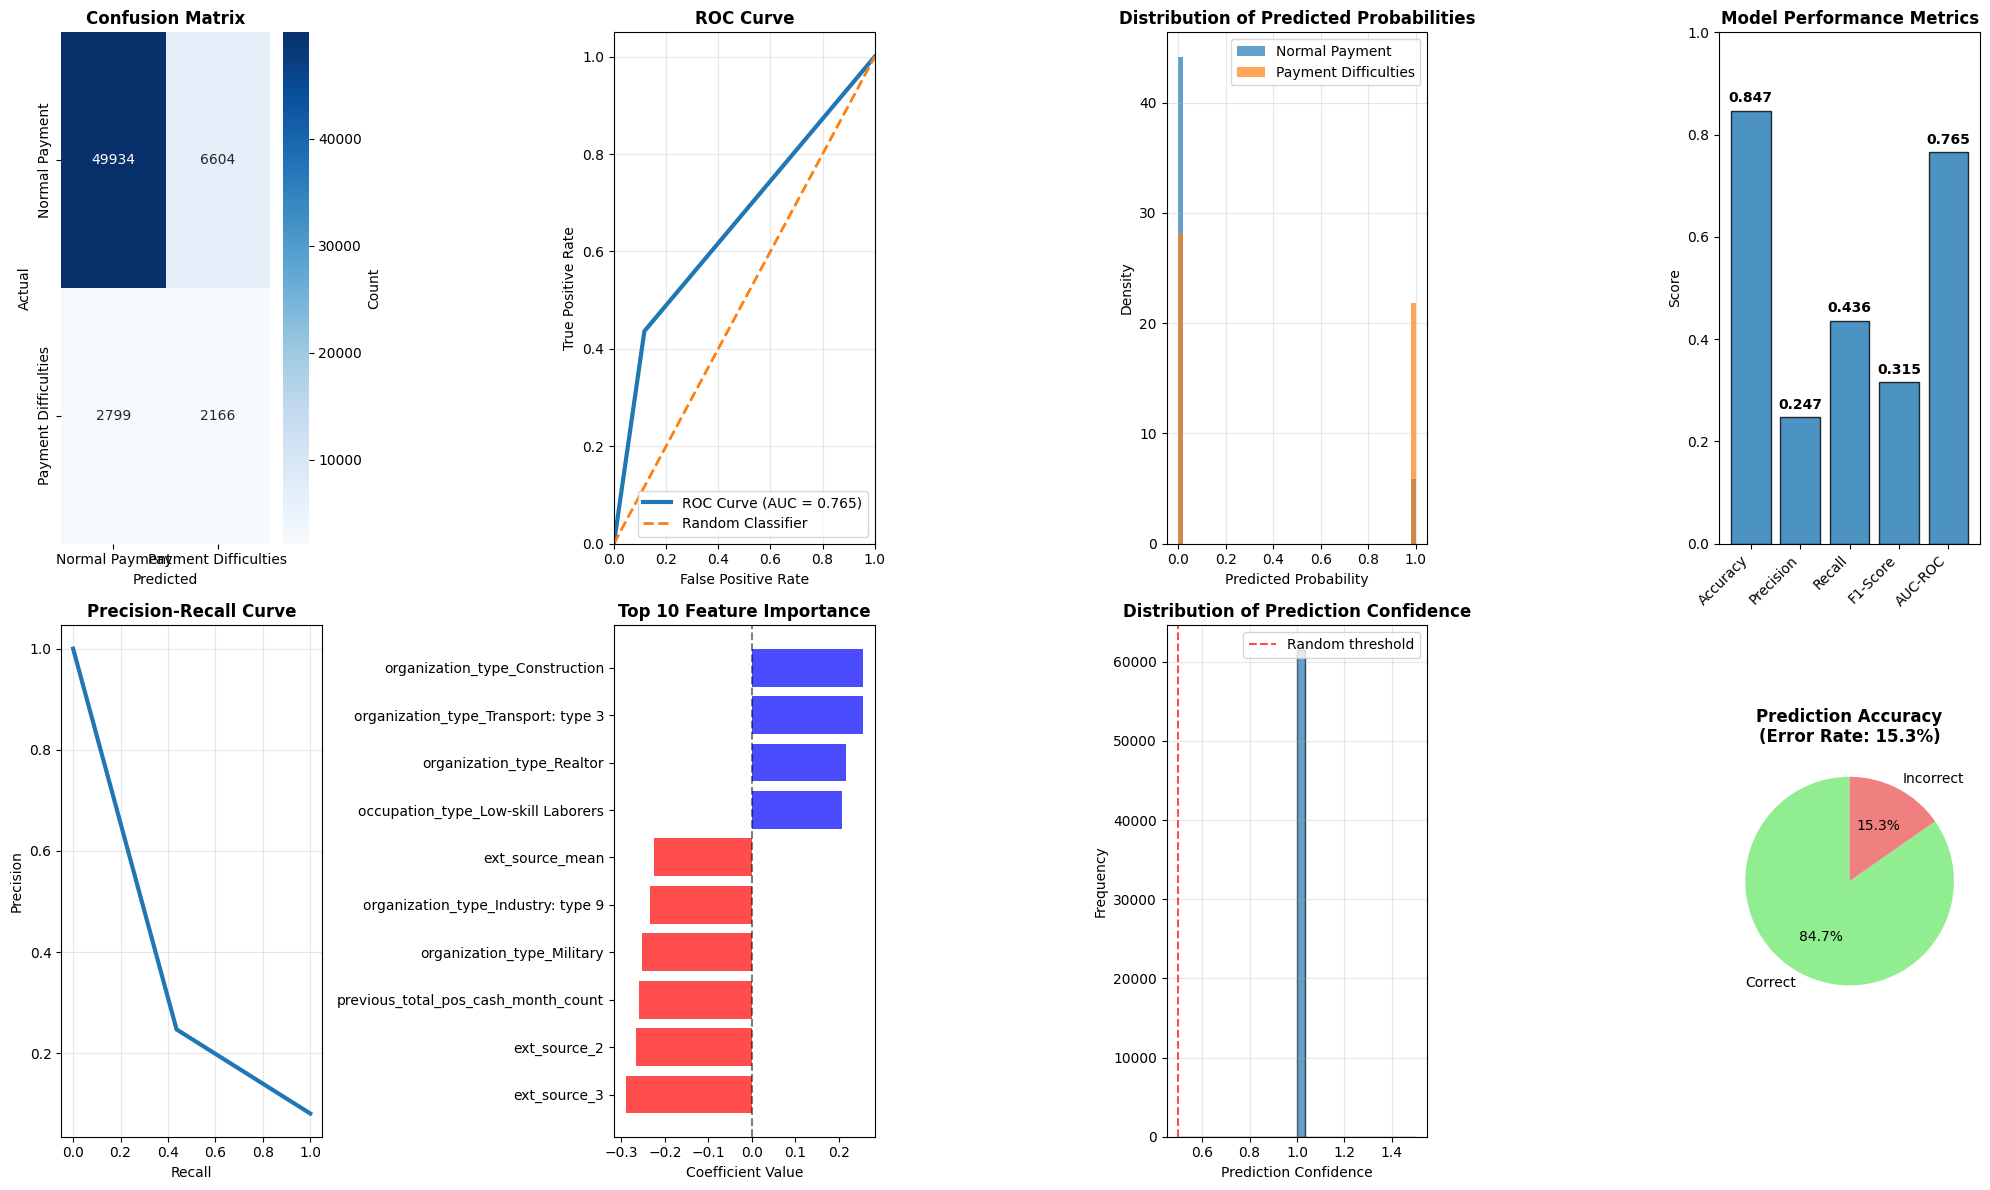


MODEL EVALUATION INSIGHTS:
• Model shows good performance (AUC: 0.765)
• Low precision: 0.247
• Low recall: 0.436
• F1-Score: 0.315 (Needs improvement)
• Accuracy: 0.847


In [123]:
print("\nCREATING EVALUATION VISUALIZATIONS")
print("=" * 50)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Create comprehensive evaluation plots
plt.figure(figsize=(20, 12))

# Plot 1: Confusion Matrix
plt.subplot(2, 4, 1)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal Payment', 'Payment Difficulties'],
    yticklabels=['Normal Payment', 'Payment Difficulties'],
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix', fontsize=12, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Plot 2: ROC Curve
plt.subplot(2, 4, 2)
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, lw=3, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontsize=12, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Plot 3: Distribution of predicted probabilities
plt.subplot(2, 4, 3)
plt.hist(y_prob[y_test == 0], bins=50, alpha=0.7, label='Normal Payment', density=True)
plt.hist(y_prob[y_test == 1], bins=50, alpha=0.7, label='Payment Difficulties', density=True)
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.title('Distribution of Predicted Probabilities', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: Metrics comparison
plt.subplot(2, 4, 4)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
values = [accuracy, precision, recall, f1, auc_score]

bars = plt.bar(metrics, values, alpha=0.8, edgecolor='black')
plt.title('Model Performance Metrics', fontsize=12, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{value:.3f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# Plot 5: Precision-Recall Curve
plt.subplot(2, 4, 5)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
plt.plot(recall_vals, precision_vals, lw=3)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# Plot 6: Feature importance (top 10)
plt.subplot(2, 4, 6)

feature_importance = pd.DataFrame({
    'Feature': X_train_processed.columns,
    'Coefficient': lr.coef_[0],
    'Abs_Coefficient': np.abs(lr.coef_[0])
})

top_features = feature_importance.nlargest(10, 'Abs_Coefficient').sort_values('Coefficient')

bar_colors = ['red' if x < 0 else 'blue' for x in top_features['Coefficient']]

plt.barh(top_features['Feature'], top_features['Coefficient'], color=bar_colors, alpha=0.7)
plt.xlabel('Coefficient Value')
plt.title('Top 10 Feature Importance', fontsize=12, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)

# Plot 7: Prediction confidence distribution
plt.subplot(2, 4, 7)
confidence = np.maximum(y_prob, 1 - y_prob)
plt.hist(confidence, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Prediction Confidence')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Confidence', fontsize=12, fontweight='bold')
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Random threshold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 8: Error analysis
plt.subplot(2, 4, 8)
errors = (y_test != y_pred).astype(int)
error_rate = errors.mean()
correct_rate = 1 - error_rate

plt.pie(
    [correct_rate, error_rate],
    labels=['Correct', 'Incorrect'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['lightgreen', 'lightcoral']
)
plt.title(f'Prediction Accuracy\n(Error Rate: {error_rate:.1%})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Analysis and insights
print("\nMODEL EVALUATION INSIGHTS:")
print("=" * 50)
print(f"• Model shows {'good' if auc_score > 0.7 else 'moderate' if auc_score > 0.6 else 'poor'} performance (AUC: {auc_score:.3f})")
print(f"• {'High' if precision > 0.7 else 'Moderate' if precision > 0.5 else 'Low'} precision: {precision:.3f}")
print(f"• {'High' if recall > 0.7 else 'Moderate' if recall > 0.5 else 'Low'} recall: {recall:.3f}")
print(f"• F1-Score: {f1:.3f} ({'Good' if f1 > 0.6 else 'Needs improvement'})")
print(f"• Accuracy: {accuracy:.3f}")

### Final evaluation

In [135]:
import os
import json

from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

In [136]:
os.makedirs("../artifact", exist_ok=True)

with mlflow.start_run(run_name="logistic_final_evaluation") as eval_run:
    eval_run_id = eval_run.info.run_id

    # =========================
    # 1. Log run linkage + params
    # =========================
    mlflow.log_param("source_train_run_id", train_run_id)
    mlflow.log_param("source_threshold_run_id", threshold_run_id)
    mlflow.log_param("selected_threshold", selected_threshold)
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("test_size", 0.15)

    # =========================
    # 2. Predict on test set
    # =========================
    test_prob = best_model.predict_proba(X_test_processed)[:, 1]
    test_pred = (test_prob >= selected_threshold).astype(int)

    # =========================
    # 3. Overall metrics
    # =========================
    test_accuracy = accuracy_score(y_test, test_pred)
    test_precision = precision_score(y_test, test_pred, zero_division=0)
    test_recall = recall_score(y_test, test_pred, zero_division=0)
    test_f1 = f1_score(y_test, test_pred, zero_division=0)
    test_auc = roc_auc_score(y_test, test_prob)

    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("test_precision", test_precision)
    mlflow.log_metric("test_recall", test_recall)
    mlflow.log_metric("test_f1", test_f1)
    mlflow.log_metric("test_auc", test_auc)

    # =========================
    # 4. Per-class metrics
    # =========================
    report = classification_report(
        y_test,
        test_pred,
        output_dict=True,
        zero_division=0
    )

    for cls in ["0", "1"]:
        mlflow.log_metric(f"class_{cls}_precision", report[cls]["precision"])
        mlflow.log_metric(f"class_{cls}_recall", report[cls]["recall"])
        mlflow.log_metric(f"class_{cls}_f1", report[cls]["f1-score"])
        mlflow.log_metric(f"class_{cls}_support", report[cls]["support"])

    mlflow.log_metric("macro_avg_precision", report["macro avg"]["precision"])
    mlflow.log_metric("macro_avg_recall", report["macro avg"]["recall"])
    mlflow.log_metric("macro_avg_f1", report["macro avg"]["f1-score"])

    mlflow.log_metric("weighted_avg_precision", report["weighted avg"]["precision"])
    mlflow.log_metric("weighted_avg_recall", report["weighted avg"]["recall"])
    mlflow.log_metric("weighted_avg_f1", report["weighted avg"]["f1-score"])

    # =========================
    # 5. Confusion matrix metrics
    # =========================
    cm = confusion_matrix(y_test, test_pred)
    tn, fp, fn, tp = cm.ravel()

    mlflow.log_metric("tn", tn)
    mlflow.log_metric("fp", fp)
    mlflow.log_metric("fn", fn)
    mlflow.log_metric("tp", tp)

    # =========================
    # 6. Save artifacts
    # =========================

    # Classification report JSON
    report_path = "../artifact/logistic_classification_report.json"
    with open(report_path, "w") as f:
        json.dump(report, f, indent=4)

    mlflow.log_artifact(report_path)

    # Confusion matrix CSV
    cm_df = pd.DataFrame(
        cm,
        index=["Actual_0", "Actual_1"],
        columns=["Predicted_0", "Predicted_1"]
    )

    cm_path = "../artifact/logistic_confusion_matrix.csv"
    cm_df.to_csv(cm_path)

    mlflow.log_artifact(cm_path)

    # Test prediction result CSV
    prediction_df = pd.DataFrame({
        "y_true": y_test,
        "y_proba": test_prob,
        "y_pred": test_pred
    })

    prediction_path = "../artifact/logistic_test_predictions.csv"
    prediction_df.to_csv(prediction_path, index=False)

    mlflow.log_artifact(prediction_path)

    # ROC curve
    roc_path = "../artifact/logistic_roc_curve.png"
    RocCurveDisplay.from_predictions(y_test, test_prob)
    plt.title("ROC Curve - Logistic Regression")
    plt.savefig(roc_path, bbox_inches="tight")
    plt.close()

    mlflow.log_artifact(roc_path)

    # Precision-Recall curve
    pr_path = "../artifact/logistic_precision_recall_curve.png"
    PrecisionRecallDisplay.from_predictions(y_test, test_prob)
    plt.title("Precision-Recall Curve - Logistic Regression")
    plt.savefig(pr_path, bbox_inches="tight")
    plt.close()

    mlflow.log_artifact(pr_path)

    # =========================
    # 7. Log final model
    # =========================
    mlflow.sklearn.log_model(
        best_model,
        artifact_path="best_model"
    )

    # =========================
    # 8. Print results
    # =========================
    print("\n=== FINAL TEST RESULTS ===")
    print(f"Threshold : {selected_threshold:.2f}")
    print(f"Accuracy  : {test_accuracy:.6f}")
    print(f"Precision : {test_precision:.6f}")
    print(f"Recall    : {test_recall:.6f}")
    print(f"F1-score  : {test_f1:.6f}")
    print(f"ROC-AUC   : {test_auc:.6f}")

    print("\n=== CONFUSION MATRIX ===")
    print(cm)

    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(y_test, test_pred, digits=6, zero_division=0))

print("Evaluation run_id:", eval_run_id)

2026/04/29 17:01:59 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/04/29 17:01:59 INFO mlflow.tracking._tracking_service.client: 🏃 View run logistic_final_evaluation at: http://localhost:5002/#/experiments/868821111017111961/runs/af4bd6c2c0f34c7ea233d22b0e8ab215.
2026/04/29 17:01:59 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://localhost:5002/#/experiments/868821111017111961.



=== FINAL TEST RESULTS ===
Threshold : 0.67
Accuracy  : 0.847113
Precision : 0.246978
Recall    : 0.436254
F1-score  : 0.315399
ROC-AUC   : 0.765036

=== CONFUSION MATRIX ===
[[49934  6604]
 [ 2799  2166]]

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0   0.946921  0.883194  0.913948     56538
           1   0.246978  0.436254  0.315399      4965

    accuracy                       0.847113     61503
   macro avg   0.596950  0.659724  0.614673     61503
weighted avg   0.890416  0.847113  0.865628     61503

Evaluation run_id: af4bd6c2c0f34c7ea233d22b0e8ab215


### Load model again (If needed)

In [142]:
# Load run
run = mlflow.get_run(eval_run_id)
threshold = float(run.data.params["selected_threshold"])

# Load model
model = mlflow.sklearn.load_model(f"runs:/{eval_run_id}/best_model")

print("=== LOADED MODEL INFO ===")
print(f"Run ID     : {eval_run_id}")
print(f"Threshold  : {threshold:.2f}")
print(f"Model type : {type(model)}")

# Predict
y_prob = model.predict_proba(X_test_processed)[:, 1]
y_pred = (y_prob >= threshold).astype(int)

print("\n=== PREDICTION RESULT ===")
print(f"Total samples: {len(y_pred)}")

# Summary
print("\n=== SUMMARY ===")
print(f"Mean probability: {np.mean(y_prob):.4f}")
print(f"Positive predictions: {np.sum(y_pred)} / {len(y_pred)}")

=== LOADED MODEL INFO ===
Run ID     : af4bd6c2c0f34c7ea233d22b0e8ab215
Threshold  : 0.67
Model type : <class 'sklearn.linear_model._logistic.LogisticRegression'>

=== PREDICTION RESULT ===
Total samples: 61503

=== SUMMARY ===
Mean probability: 0.4044
Positive predictions: 8770 / 61503


## XGBoost